# Guide Éducatif : Tests d'Hypothèses et ANOVA

Ce notebook utilise des données réelles pour explorer les concepts statistiques fondamentaux.

### Concepts clés :
*   **Hypothèse Nulle ($H_0$)** : Il n'y a pas d'effet ou de différence.
*   **p-value** : La probabilité d'observer nos résultats si $H_0$ est vraie. Si $p < 0.05$, on rejette $H_0$.
*   **F-value (Statistique F)** : Le ratio de la variance entre les groupes sur la variance à l'intérieur des groupes.
*   **ANOVA** : Analyse de la variance, utilisée pour comparer les moyennes de 3 groupes ou plus.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Chargement des données California Housing (via une URL pour avoir la colonne catégorielle 'ocean_proximity')
url = 'https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv'
df = pd.read_csv(url)

# On nettoie les valeurs manquantes pour l'analyse
df = df.dropna()

print("Aperçu des données (Proximité Océan vs Valeur Médiane) :")
display(df[['ocean_proximity', 'median_house_value']].head())

Aperçu des données (Proximité Océan vs Valeur Médiane) :


,ocean_proximity,median_house_value
0,NEAR BAY,452600.0
1,NEAR BAY,358500.0
2,NEAR BAY,352100.0
3,NEAR BAY,341300.0
4,NEAR BAY,342200.0


### 1. Visualisation des Distributions
Avant de faire des stats, regardons si les moyennes semblent varier selon la catégorie.

/tmp/ipykernel_6421/1376914680.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ocean_proximity', y='median_house_value', data=df, palette='Set3')


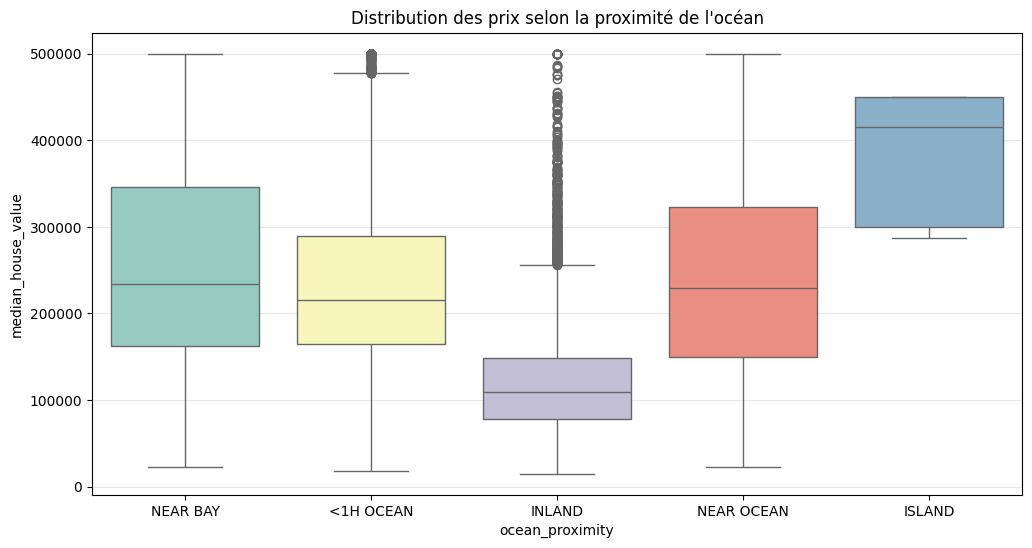

In [2]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='ocean_proximity', y='median_house_value', data=df, palette='Set3')
plt.title('Distribution des prix selon la proximité de l\'océan')
plt.grid(axis='y', alpha=0.3)
plt.show()

### 2. L'ANOVA (Analyse de la Variance)

**Question de recherche** : Le prix moyen des maisons est-il identique quel que soit l'emplacement par rapport à l'océan ?

*   $H_0$ : $\mu_{island} = \mu_{near\ ocean} = \mu_{inland} ...$
*   $H_1$ : Au moins une moyenne est différente.

In [3]:
# Création du modèle linéaire
model = ols('median_house_value ~ ocean_proximity', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("Tableau ANOVA :")
display(anova_table)

f_stat = anova_table['F'][0]
p_val = anova_table['PR(>F)'][0]

print(f"\nRésultats clés :")
print(f"F-value : {f_stat:.2f} (Plus elle est grande, plus les groupes sont distincts)")
print(f"p-value : {p_val:.4e} (Si < 0.05, le résultat est significatif)")

Tableau ANOVA :


,sum_sq,df,F,PR(>F)
ocean_proximity,6.478688e+13,4.0,1594.710397,0.0
Residual,2.074776e+14,20428.0,NaN,NaN



Résultats clés :
F-value : 1594.71 (Plus elle est grande, plus les groupes sont distincts)
p-value : 0.0000e+00 (Si < 0.05, le résultat est significatif)


/tmp/ipykernel_6421/3569469265.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f_stat = anova_table['F'][0]
/tmp/ipykernel_6421/3569469265.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_val = anova_table['PR(>F)'][0]


### 3. Test Post-Hoc (Tukey HSD)
L'ANOVA est significative, mais quels groupes sont réellement différents ? Le test de Tukey compare toutes les paires possibles.

           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
  group1    group2     meandiff   p-adj     lower        upper     reject
-------------------------------------------------------------------------
<1H OCEAN     INLAND -115371.1277    0.0 -119843.5475 -110898.7078   True
<1H OCEAN     ISLAND  140172.0092 0.0161   17186.1894   263157.829   True
<1H OCEAN   NEAR BAY   19011.3013    0.0   12556.4982   25466.1043   True
<1H OCEAN NEAR OCEAN    8774.3642 0.0008    2681.0484     14867.68   True
   INLAND     ISLAND  255543.1369    0.0  132544.0279  378542.2458   True
   INLAND   NEAR BAY  134382.4289    0.0  127679.1902  141085.6677   True
   INLAND NEAR OCEAN  124145.4919    0.0   117789.595  130501.3888   True
   ISLAND   NEAR BAY -121160.7079 0.0562 -244247.8427    1926.4268  False
   ISLAND NEAR OCEAN  -131397.645 0.0295 -254466.3524   -8328.9375   True
 NEAR BAY NEAR OCEAN   -10236.937 0.0036  -18114.7139   -2359.1602   True
--------------------------------------

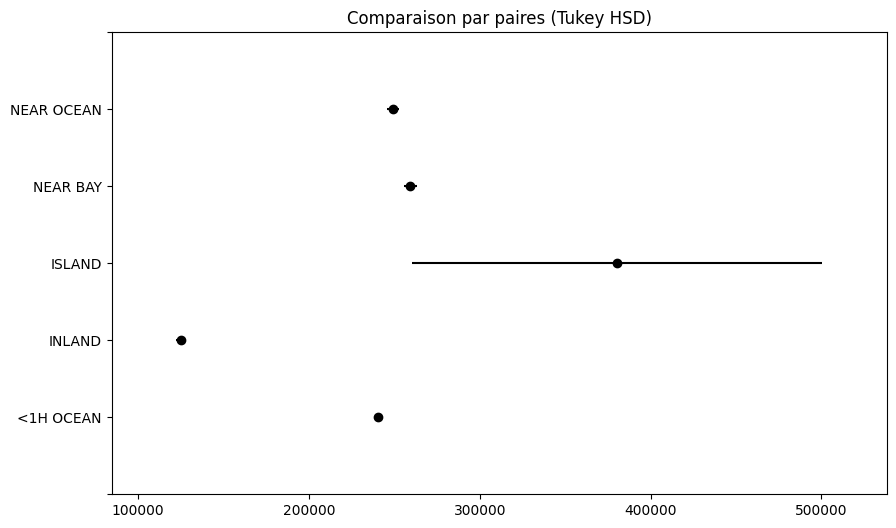

In [4]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Exécution du test de Tukey
tukey = pairwise_tukeyhsd(endog=df['median_house_value'],
                          groups=df['ocean_proximity'],
                          alpha=0.05)

print(tukey)

# Visualisation des intervalles de confiance
tukey.plot_simultaneous()
plt.title("Comparaison par paires (Tukey HSD)")
plt.show()

### 4. Vérification des Hypothèses (Diagnostics)
Pour qu'une ANOVA soit fiable, les résidus (erreurs) doivent idéalement suivre une distribution normale.

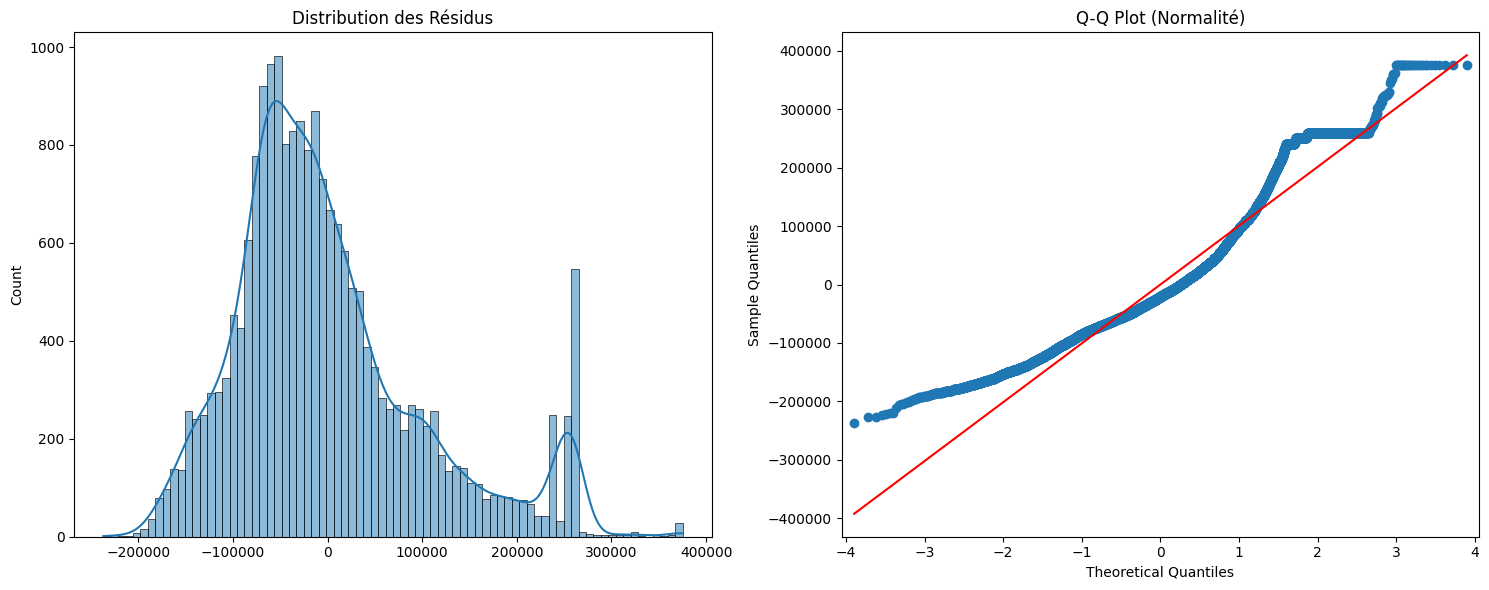

p-value test de normalité (Shapiro) : 3.7425e-47


In [5]:
residus = model.resid

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histogramme des résidus
sns.histplot(residus, kde=True, ax=ax1)
ax1.set_title('Distribution des Résidus')

# Q-Q Plot
sm.qqplot(residus, line='s', ax=ax2)
ax2.set_title('Q-Q Plot (Normalité)')

plt.tight_layout()
plt.show()

# Test de Shapiro-Wilk (numérique)
# Note : sur de très grands échantillons, ce test est souvent trop sensible
_, p_norm = stats.shapiro(residus[:5000]) # On limite à 5000 points pour le test
print(f"p-value test de normalité (Shapiro) : {p_norm:.4e}")